In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot_v2 

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [140]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [184]:
end = datetime.date(2025, 10, 16)
start = end - datetime.timedelta(days=180) 

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
        
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="7Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/30Y", value=IRSwapValue.SPREADOVER),
        
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT7", value=IRSwapValue.MMSS),
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT7/CT10", value=IRSwapValue.MMSS),
        
		IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
    ],
    n_jobs=1,
    # ignore_cache=True
)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 3/3 [00:00<00:00, 73.33it/s]
PRICING FIXED-RATE BONDS.: 0it [00:00, ?it/s]


SWAPSPREADS                                 \
           USD-SOFR-1D CT5 OUTRIGHT MMSS USD-SOFR-1D CT30 OUTRIGHT MMSS   
Date                                                                      
2025-04-21                    -41.687167                     -93.057027   
2025-04-22                    -39.774838                     -90.997289   
2025-04-23                    -38.301672                     -86.915199   
2025-04-24                    -37.552744                     -85.608521   
2025-04-25                    -37.343977                     -85.807084   
...                                  ...                            ...   
2025-10-09                    -34.492080                     -75.980935   
2025-10-10                    -34.755911                     -76.216438   
2025-10-14                    -33.360743                     -74.566576   
2025-10-15                    -34.423807                     -74.603273   
2025-10-16                    -34.967814                     -75.131133   

                                            
           USD-SOFR-1D CT5/CT30 CURVE MMSS  
Date                                        
2025-04-21                      -51.369860  
2025-04-22                      -51.222452  
2025-04-23                      -48.613526  
2025-04-24                      -48.055777  
2025-04-25                      -48.463107  
...                                    ...  
2025-10-09                      -41.488855  
2025-10-10                      -41.460527  
2025-10-14                      -41.205833  
2025-10-15                      -40.179466  
2025-10-16                      -40.063319  

[124 rows x 3 columns]

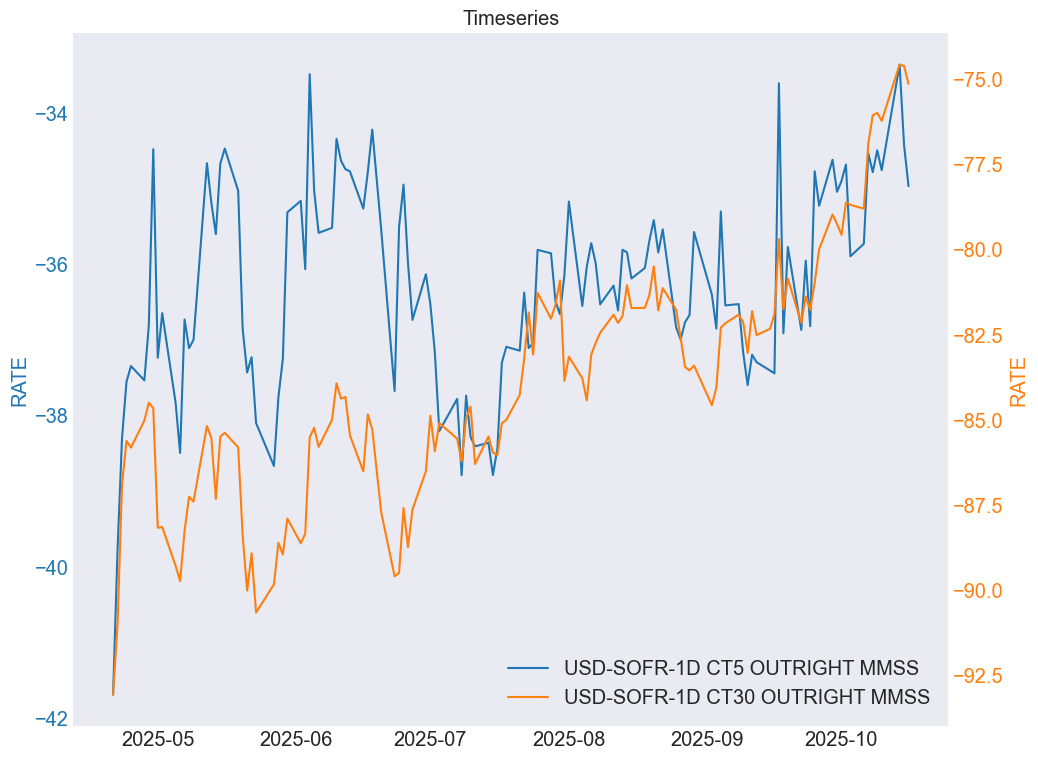

In [214]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot_v2(
    ylabel_left="RATE",
    ylabel_right="RATE",
    title="Timeseries"
)

# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5 OUTRIGHT MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT7/CT10 FLY MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 2Y/5Y/7Y FLY SPREADOVER"], which="right")

# plot(df["SWAPSPREADS"]["USD-SOFR-1D 30Y OUTRIGHT SPREADOVER"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y OUTRIGHT SPREADOVER"], which="right")
plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5 OUTRIGHT MMSS"], which="left")
plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT MMSS"], which="right")

# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT30 CURVE MMSS"], which="right")

# plot(df["IRS"]["USD-SOFR-1D 5Y OUTRIGHT RATE"])
# plot(df["IRS"]["USD-SOFR-1D 10Y OUTRIGHT RATE"])
# plot(df["IRS"]["USD-SOFR-1D 30Y OUTRIGHT RATE"])
# plot(df["IRS"]["USD-SOFR-1D 2Y OUTRIGHT RATE"])

legend()
plt.show()




# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])

Beta: [0.08399957 1.09890109]
Beta Std Error: [0.08790107 0.09257269]
Beta Covariance: [[124322.06662226  -7753.74520641]
 [ -7753.74520641 137887.75470735]]
Residual Variance: 6.214985189555512e-08
Inverse Condition #: 0.9393192677991661
Reason(s) for Halting:
  Sum of squares convergence


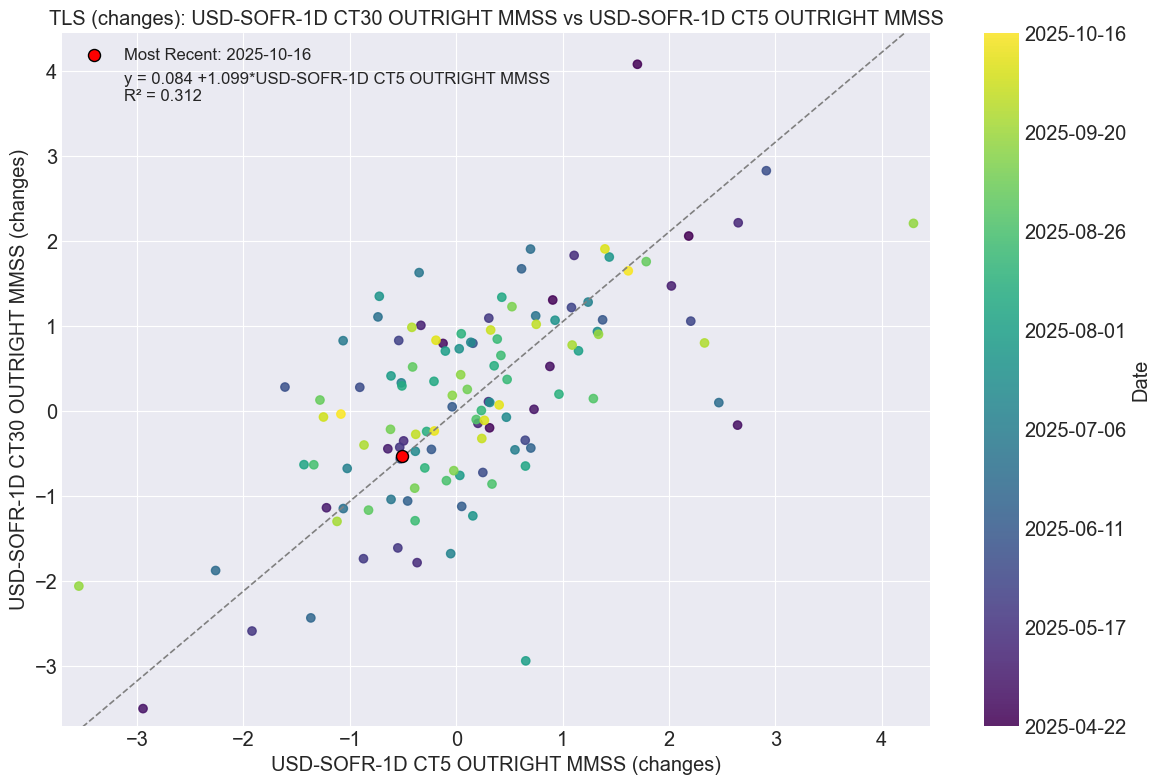

In [212]:
# from RVUtils.regression import make_linear_regression_builder
# from RVUtils.arbl_hedge_ratios import get_tls_hedge_ratio

# add_x, fit, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
#     df=df["SWAPSPREADS"], y_col="USD-SOFR-1D CT30 OUTRIGHT MMSS", date_color_bar=True, on_diff=True
# )
# add_x("USD-SOFR-1D CT5 OUTRIGHT MMSS")

# res = fit(model="TLS", verbose=True)
# plot_avp()
# # plot_resid_ts(
# #     # plot_zscores=True,
# #     # stds=(1, 2),
# #     ou_bands=True,
# #     ou_steps=126,
# # )

from RVUtils.regression import make_linear_regression_builder
import gs_quant.timeseries.econometrics as gsqtse

add_x, fit_, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
    df=df["SWAPSPREADS"],
    y_col="USD-SOFR-1D CT30 OUTRIGHT MMSS",
    date_color_bar=True,
    on_diff=True,
    add_constant=True,
)

add_x("USD-SOFR-1D CT5 OUTRIGHT MMSS")
_ = fit_(model="OLS")
X_used, y_used, _ = get_data()
X_no_const = X_used.drop(columns=["const"], errors="ignore")

def rvol_abs(s, w=60, floor=1e-8):
    v = gsqtse.volatility(x=s, w=w, returns_type=gsqtse.Returns.ABSOLUTE)
    return v.reindex(y_used.index).bfill().clip(lower=floor)

sx = np.column_stack([rvol_abs(X_no_const[c]).values for c in X_no_const.columns])
sy = rvol_abs(y_used).values

res_deming = fit_(model="TLS", tls_x_errs=sx, tls_y_errs=sy, verbose=True)
plot_avp()

In [207]:
import gs_quant.timeseries
import gs_quant.timeseries.econometrics as gsqtse

gsqtse.Returns.ABSOLUTE

gsqtse.volatility(x=df["SWAPSPREADS"]["USD-SOFR-1D CT5 OUTRIGHT MMSS"], w=60, returns_type=gsqtse.Returns.ABSOLUTE).tail(1) / 100

Date
2025-10-16    15.679195
Name: USD-SOFR-1D CT5 OUTRIGHT MMSS, dtype: float64